In [1]:
from sklearn.preprocessing import PowerTransformer, StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import  GaussianNB


In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()


In [3]:
df_num = pd.DataFrame(data.data, columns=data.feature_names)

df_num['target'] = data.target

In [4]:
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
df_num.duplicated().sum()

np.int64(0)

<Axes: >

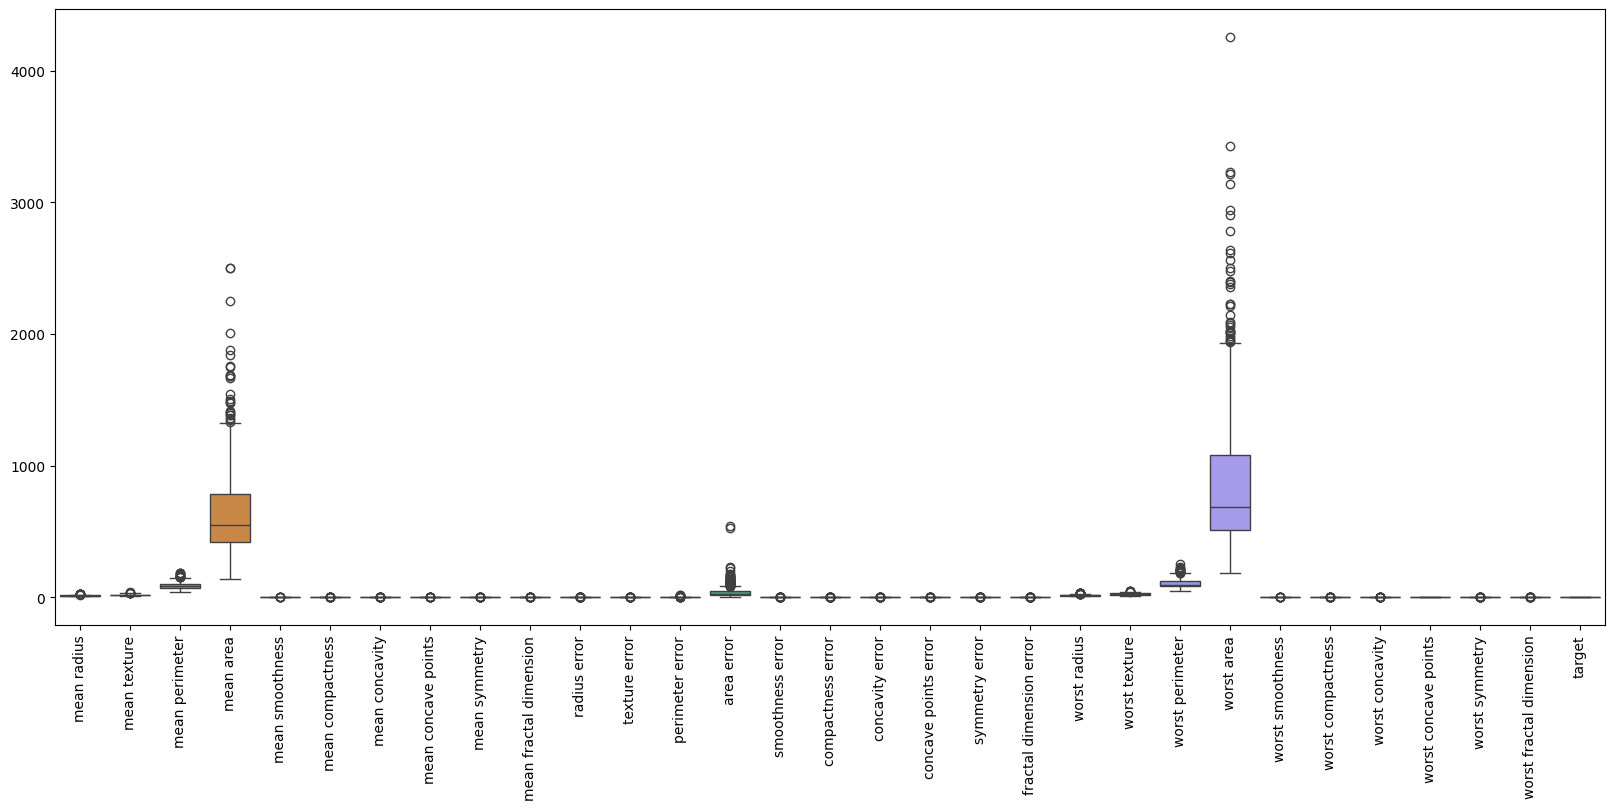

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,8))
plt.xticks(rotation = 90)

sns.boxplot(df_num)

In [7]:
X_num = df_num.drop("target" ,axis=1 )
y_num = df_num["target"]

In [8]:
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(X_num, y_num, test_size=0.2, random_state=42)

In [9]:
y_train_num = pd.DataFrame(y_train_num)

In [10]:
y_train_num["target"].value_counts()

target
1    286
0    169
Name: count, dtype: int64

In [11]:
smote = SMOTE(random_state=42)
X_train_smoted, y_train_smoted = smote.fit_resample(X_train_num, y_train_num)

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [12]:
y_train_smoted["target"].value_counts()

target
1    286
0    286
Name: count, dtype: int64

In [13]:
pt = PowerTransformer(method='yeo-johnson') 
X_train_transformed = pt.fit_transform(X_train_smoted)
X_test_transformed = pt.transform(X_test_num)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_transformed)
X_test_scaled = scaler.transform(X_test_transformed)

In [15]:
from sklearn.naive_bayes import  GaussianNB
gaussian_nb = GaussianNB()

In [16]:
gaussian_nb.fit(X_train_scaled, y_train_smoted)

y_pred = gaussian_nb.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test_num, y_pred):.2%}")
print(classification_report(y_test_num, y_pred))

Accuracy: 97.37%
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
